# IT3051 – Fundamentals of Data Mining | Mini Project 2026
## Stage 7 – Model Optimisation & Final Model Selection
**Group:** Mine4Data (DS.Y3S2.01.01) · **Project:** Airbnb Listing Price Prediction · **Builds on:** `03_Modelling_Airbnb.ipynb` (Stage 6 baselines)

Stage 6 compared seven algorithms with default settings. This notebook:
1. **tunes the hyper-parameters** of every model that has any, using a search strategy suited to each model;
2. **compares the tuned models with their Stage 6 baselines**;
3. **tests whether feature engineering, feature selection or other modelling choices** (feature set, amenity vocabulary, ensembling) improve the best model;
4. **selects and justifies the final model**, then evaluates it **once** on the untouched test set;
5. **interprets** the final model and **saves** it, with its preprocessing, for the Stage 9 backend.

All tuning uses the **same 5 folds of the training set** as Stage 6 (`md.CV`). The test set is used only in §9, after the choice has been made.

| # | Section | Stage 7 checklist item |
|---|---|---|
| 1 | Setup | – |
| 2 | Search strategy | appropriate optimisation / search strategy |
| 3 | Linear models: Ridge & Lasso (grid search) | hyper-parameter tuning |
| 4 | K-Nearest Neighbours (grid search) | hyper-parameter tuning |
| 5 | Tree ensembles: Random Forest, HistGradientBoosting, XGBoost (randomised search) | hyper-parameter tuning |
| 6 | Tuned vs baseline models | compare tuned models with baseline models |
| 7 | Do feature engineering, feature selection or other choices help? | investigate feature selection / engineering / modelling choices |
| 8 | Final model selection | select the final model · justify the selection |
| 9 | Final evaluation on the test set (used once) | – |
| 10 | Interpreting the final model | interpretation of results |
| 11 | Saving the final model for the backend | deliverable: trained final model |
| 12 | Summary of Stage 7 decisions, limitations and future work | – |

## 1. Setup

In [1]:
import json
import platform
import shutil
import tempfile
import time
import warnings
from datetime import date
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
from joblib import Memory
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

from src import preprocessing as pp
from src import modelling as md

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

FIG_DIR, RESULTS_DIR, MODEL_DIR = Path("figures/optimisation"), Path("results"), Path("models")
for d in (FIG_DIR, RESULTS_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, BLUE_LIGHT, ORANGE, AQUA, RED = "#2a78d6", "#86b6ef", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "text.color": INK,
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", RED]),
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

RANDOM_STATE = md.RANDOM_STATE
X_train, X_test, y_train, y_test = md.load_split()
stage6 = pd.read_csv(RESULTS_DIR / "stage6_cv_summary.csv", index_col=0)
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows (locked until §9)")
stage6[["family", "RMSE (log)", "R²", "MAE ($)"]]

Train: 59,287 rows | Test: 14,822 rows (locked until §9)


,family,RMSE (log),R²,MAE ($)
XGBoost,boosting ensemble,0.3929,0.7014,49.9365
Random Forest,bagging ensemble,0.3931,0.7012,50.0154
HistGradientBoosting,boosting ensemble,0.3935,0.7005,50.0024
Linear Regression,linear,0.4168,0.6641,53.4194
Ridge,linear,0.4172,0.6634,53.5089
Lasso,linear,0.4183,0.6615,53.6357
KNN,instance-based,0.4472,0.6133,56.3818
Mean baseline,baseline,0.7191,-0.0002,88.6457


## 2. Search strategy

| Model | Hyper-parameters searched | Strategy | Why this strategy |
|---|---|---|---|
| Linear Regression | – (none) | – | Ordinary least squares has no hyper-parameter; it stays as the reference. |
| Ridge | `alpha` (L2 strength), 1e-2 … 1e3 | **Grid search**, 11 log-spaced values | One parameter and cheap fits: an exhaustive log-scale grid covers weak to strong regularisation. |
| Lasso | `alpha` (L1 strength), 1e-4 … 1e-1 | **Grid search**, 7 log-spaced values | As for Ridge. Smaller values were dropped: below 1e-4 coordinate descent does not converge in 5,000 iterations (~2 min per fit), and such a weak penalty is practically OLS. The chosen `alpha` also decides how many features Lasso **keeps** (embedded selection). |
| KNN | `n_neighbors`, `weights` | **Grid search**, 4 × 2 | Two parameters with few sensible values. |
| Random Forest | trees, `max_features`, `min_samples_leaf`, `max_depth` | **Randomised search**, 6 candidates | Each fit is expensive (~30 s), so a full grid is not feasible. |
| HistGradientBoosting | learning rate, iterations, leaves, min leaf size, L2, feature subsampling | **Randomised search**, 15 candidates | 6 interacting parameters. A grid with 4 values each would need 4,096 × 5 fits. Random search explores each important dimension with far fewer trials (Bergstra & Bengio, 2012). |
| XGBoost | trees, learning rate, depth, min child weight, row/column subsampling, L1/L2 | **Randomised search**, 20 candidates | As above (8 parameters). Continuous ranges use log-uniform distributions, because learning rate and regularisation act multiplicatively. |

**Common rules for every search**
- **Objective:** minimise 5-fold CV **RMSE (log)** on the training set. MAE and R² are recorded too.
- **The same folds as Stage 6** (`md.CV`), so tuned and untuned scores are directly comparable.
- **The whole pipeline is searched**, so preprocessing is refitted inside every fold. To save time, the fitted preprocessor for each fold is **cached** (`Pipeline(memory=…)`). The cache key includes the fold's training rows, so it is reused only when *exactly the same* training fold is refitted with a different model setting. The search is therefore still leakage-free.
- `random_state = 42` everywhere, so every search is reproducible.

In [2]:
N_ITER = {"Random Forest": 6, "HistGradientBoosting": 15, "XGBoost": 20}
SCORING = {"RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error", "R2": "r2"}
CACHE_DIR = Path(tempfile.mkdtemp(prefix="airbnb_prep_cache_"))
CACHE = Memory(location=CACHE_DIR, verbose=0)
searches, search_time = {}, {}

def run_search(name, space, randomised=False):
    pipe = md.make_pipeline(name, "listing", memory=CACHE)
    if randomised:
        search = RandomizedSearchCV(pipe, space, n_iter=N_ITER[name], scoring=SCORING, refit="RMSE",
                                    cv=md.CV, random_state=RANDOM_STATE, n_jobs=1)
    else:
        search = GridSearchCV(pipe, space, scoring=SCORING, refit="RMSE", cv=md.CV, n_jobs=1)
    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    searches[name], search_time[name] = search, time.perf_counter() - t0
    res = pd.DataFrame(search.cv_results_)
    res.drop(columns="params").to_csv(RESULTS_DIR / f"stage7_search_{name.replace(' ', '_').lower()}.csv", index=False)
    print(f"{name}: {len(res)} candidates × 5 folds in {search_time[name]:.0f} s | "
          f"best CV RMSE {-search.best_score_:.4f} (Stage 6: {stage6.loc[name, 'RMSE (log)']:.4f})")
    print("best params:", {k.replace('model__', ''): (round(v, 5) if isinstance(v, float) else v) for k, v in search.best_params_.items()})
    return res

## 3. Linear models: Ridge & Lasso (grid search)

Ridge: 11 candidates × 5 folds in 135 s | best CV RMSE 0.4168 (Stage 6: 0.4172)
best params: {'alpha': np.float64(0.01)}


Lasso: 7 candidates × 5 folds in 123 s | best CV RMSE 0.4173 (Stage 6: 0.4183)
best params: {'alpha': np.float64(0.0001)}
Lasso keeps 78 of 87 features at the chosen alpha


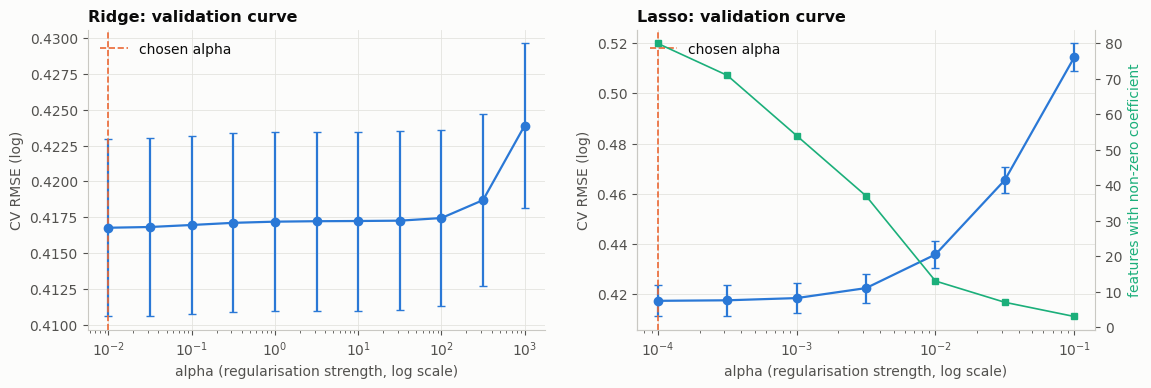

In [3]:
res_ridge = run_search("Ridge", {"model__alpha": np.logspace(-2, 3, 11)})
res_lasso = run_search("Lasso", {"model__alpha": np.logspace(-4, -1, 7)})

lasso_best = searches["Lasso"].best_estimator_.named_steps["model"]
n_in = len(lasso_best.coef_)
print(f"Lasso keeps {np.sum(lasso_best.coef_ != 0)} of {n_in} features at the chosen alpha")

# how many features survive at each alpha (fitted on the full training set: illustration only, not used for selection)
Z_lin = searches["Lasso"].best_estimator_.named_steps["prep"].transform(X_train)
kept = {a: int(np.sum(clone(lasso_best).set_params(alpha=a).fit(Z_lin, y_train).coef_ != 0)) for a in np.logspace(-4, -1, 7)}

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
for ax, res, name in [(axes[0], res_ridge, "Ridge"), (axes[1], res_lasso, "Lasso")]:
    a = res["param_model__alpha"].astype(float)
    ax.errorbar(a, -res["mean_test_RMSE"], yerr=res["std_test_RMSE"], marker="o", color=BLUE, capsize=3, lw=1.6)
    ax.axvline(searches[name].best_params_["model__alpha"], color=ORANGE, ls="--", lw=1.2, label="chosen alpha")
    ax.set_xscale("log"); ax.set_xlabel("alpha (regularisation strength, log scale)"); ax.set_ylabel("CV RMSE (log)")
    ax.set_title(f"{name}: validation curve"); ax.legend(loc="upper left")
ax2 = axes[1].twinx(); ax2.grid(False)
ax2.plot(list(kept), list(kept.values()), color=AQUA, marker="s", lw=1.2, ms=4, label="features kept")
ax2.set_ylabel("features with non-zero coefficient", color=AQUA); ax2.spines["right"].set_visible(True)
save(fig, "03_linear_validation_curves")

**Reading the result**
- **Ridge:** the validation curve is flat from α = 0.01 to α = 100 (CV RMSE 0.4168–0.4174), and the error rises only for very strong penalties. The chosen α = 0.01 is practically ordinary least squares. This confirms Stage 6 §6: **the linear models are not over-fitting**, so there is nothing for L2 regularisation to fix. Their limit is bias, not variance.
- **Lasso:** the weakest penalty tested (α = 1e-4) is best (0.4173). It keeps **78 of 87 features**. The green line shows Lasso's **embedded feature selection**: at α = 1e-3 it keeps only ~54 features and loses just 0.001 RMSE (0.4184). About a third of the columns, mostly amenity flags, can be removed from a *linear* model at almost no cost. Stronger penalties remove useful features and the error climbs quickly (α = 0.1 keeps 3 features, RMSE 0.514).
- **Gain from tuning: +0.1% (Ridge) and +0.3% (Lasso).** Tuning cannot rescue an under-fitting model family.

## 4. K-Nearest Neighbours (grid search)

KNN: 8 candidates × 5 folds in 126 s | best CV RMSE 0.4283 (Stage 6: 0.4472)
best params: {'n_neighbors': 20, 'weights': 'distance'}


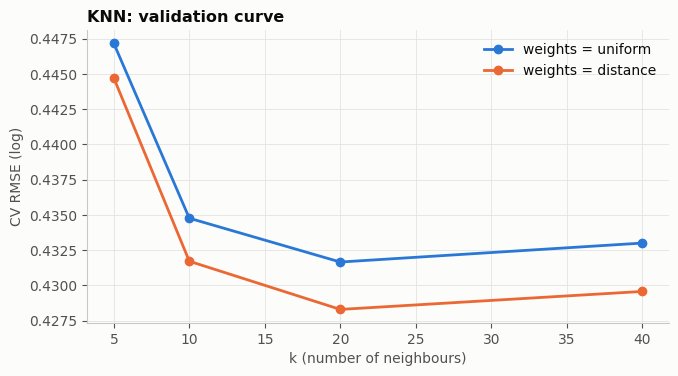

In [4]:
res_knn = run_search("KNN", {"model__n_neighbors": [5, 10, 20, 40], "model__weights": ["uniform", "distance"]})
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for w, col in [("uniform", BLUE), ("distance", ORANGE)]:
    r = res_knn[res_knn["param_model__weights"] == w]
    ax.plot(r["param_model__n_neighbors"].astype(int), -r["mean_test_RMSE"], marker="o", color=col, label=f"weights = {w}")
ax.set_xlabel("k (number of neighbours)"); ax.set_ylabel("CV RMSE (log)"); ax.set_title("KNN: validation curve"); ax.legend()
save(fig, "04_knn_validation_curve")

**Reading the result**
- **More neighbours help up to k = 20:** RMSE falls from 0.447 (k = 5) to 0.428 (k = 20, distance-weighted), then rises again at k = 40. Averaging over more "comparable" listings reduces the noise of any single neighbour (variance). With too many neighbours, the comparables stop being similar (bias).
- **Distance weighting is better at every k** (by ~0.003). Closer listings get more say, which is how a host would price against comparables.
- **The 4.2% improvement is the largest of any model, but KNN is still the weakest real model** (0.428 vs 0.383 for XGBoost). The basic problem, an equal-weight distance over 87 mostly binary features, is not something tuning can change.

## 5. Tree ensembles (randomised search)
### 5a. Random Forest

In [5]:
res_rf = run_search("Random Forest", {
    "model__n_estimators": [200, 300],
    "model__max_features": [0.2, 1 / 3, 0.5],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_depth": [None, 25],
}, randomised=True)
cols = ["param_model__n_estimators", "param_model__max_features", "param_model__min_samples_leaf", "param_model__max_depth",
        "mean_test_RMSE", "std_test_RMSE", "mean_fit_time"]
res_rf.sort_values("rank_test_RMSE")[cols].assign(mean_test_RMSE=lambda d: -d["mean_test_RMSE"])

Random Forest: 6 candidates × 5 folds in 1041 s | best CV RMSE 0.3922 (Stage 6: 0.3931)
best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.2, 'max_depth': 25}


,param_model__n_estimators,param_model__max_features,param_model__min_samples_leaf,param_model__max_depth,mean_test_RMSE,std_test_RMSE,mean_fit_time
4,200,0.2000,1,25,0.3922,0.0070,8.2685
0,300,0.2000,2,25,0.3926,0.0070,12.9688
2,200,0.2000,2,25,0.3928,0.0071,130.4581
3,300,0.5000,2,25,0.3938,0.0071,14.4184
5,300,0.3333,4,25,0.3942,0.0070,11.7519
1,200,0.5000,1,25,0.3945,0.0067,22.2360


### 5b. HistGradientBoosting

In [6]:
res_hgb = run_search("HistGradientBoosting", {
    "model__learning_rate": loguniform(0.03, 0.2),
    "model__max_iter": randint(200, 800),           # upper bound: early stopping (10% internal validation) ends training sooner
    "model__max_leaf_nodes": randint(15, 128),
    "model__min_samples_leaf": randint(10, 100),
    "model__l2_regularization": loguniform(1e-3, 10),
    "model__max_features": uniform(0.4, 0.6),       # share of features considered per split: 0.4 – 1.0
}, randomised=True)
cols = [c for c in res_hgb if c.startswith("param_")] + ["mean_test_RMSE", "std_test_RMSE", "mean_fit_time"]
res_hgb.sort_values("rank_test_RMSE")[cols].head(8).assign(mean_test_RMSE=lambda d: -d["mean_test_RMSE"])

HistGradientBoosting: 15 candidates × 5 folds in 400 s | best CV RMSE 0.3866 (Stage 6: 0.3935)
best params: {'l2_regularization': np.float64(0.00608), 'learning_rate': np.float64(0.03269), 'max_features': np.float64(0.5952), 'max_iter': 537, 'max_leaf_nodes': 125, 'min_samples_leaf': 62}


,param_model__l2_regularization,param_model__learning_rate,param_model__max_features,param_model__max_iter,param_model__max_leaf_nodes,param_model__min_samples_leaf,mean_test_RMSE,std_test_RMSE,mean_fit_time
11,0.0061,0.0327,0.5952,537,125,62,0.3866,0.0056,10.3412
3,0.2951,0.0957,0.4042,760,105,68,0.3882,0.0059,4.4170
1,0.0025,0.0717,0.6002,330,36,62,0.3884,0.0057,4.5478
7,0.0012,0.0465,0.5446,654,58,17,0.3885,0.0062,5.9074
9,0.0068,0.0881,0.4188,601,104,53,0.3885,0.0061,4.3082
4,0.0398,0.0328,0.9843,389,76,56,0.3886,0.0057,7.6861
6,0.5263,0.0705,0.4080,515,28,18,0.3892,0.0058,4.6179
2,7.5795,0.1455,0.5274,391,74,30,0.3895,0.0058,3.3055


### 5c. XGBoost

In [7]:
res_xgb = run_search("XGBoost", {
    "model__n_estimators": randint(300, 1500),
    "model__learning_rate": loguniform(0.01, 0.15),
    "model__max_depth": randint(4, 11),
    "model__min_child_weight": randint(1, 30),
    "model__subsample": uniform(0.6, 0.4),          # 0.6 – 1.0 of rows per tree
    "model__colsample_bytree": uniform(0.4, 0.6),   # 0.4 – 1.0 of features per tree
    "model__reg_lambda": loguniform(0.1, 20),
    "model__reg_alpha": loguniform(1e-3, 1),
}, randomised=True)
cols = [c for c in res_xgb if c.startswith("param_")] + ["mean_test_RMSE", "std_test_RMSE", "mean_fit_time"]
res_xgb.sort_values("rank_test_RMSE")[cols].head(8).assign(mean_test_RMSE=lambda d: -d["mean_test_RMSE"])

XGBoost: 20 candidates × 5 folds in 884 s | best CV RMSE 0.3834 (Stage 6: 0.3929)
best params: {'colsample_bytree': np.float64(0.4837), 'learning_rate': np.float64(0.02206), 'max_depth': 10, 'min_child_weight': 15, 'n_estimators': 1257, 'reg_alpha': np.float64(0.00397), 'reg_lambda': np.float64(1.525), 'subsample': np.float64(0.83697)}


,param_model__colsample_bytree,param_model__learning_rate,param_model__max_depth,param_model__min_child_weight,param_model__n_estimators,param_model__reg_alpha,param_model__reg_lambda,param_model__subsample,mean_test_RMSE,std_test_RMSE,mean_fit_time
3,0.4837,0.0221,10,15,1257,0.0040,1.5250,0.8370,0.3834,0.0062,12.8523
10,0.8633,0.0171,10,11,892,0.1362,6.5799,0.8424,0.3839,0.0059,10.9551
4,0.4279,0.0518,8,9,466,0.0011,14.7243,0.8253,0.3846,0.0065,5.0283
12,0.5866,0.0241,6,12,1025,0.4588,1.2206,0.6478,0.3855,0.0061,7.1624
14,0.4665,0.0329,6,7,863,0.0490,3.9848,0.6557,0.3856,0.0063,6.2217
1,0.9197,0.0509,6,22,1069,0.1466,14.4424,0.6003,0.3856,0.0056,7.3307
17,0.9300,0.0241,10,28,489,0.0021,0.3346,0.7708,0.3857,0.0056,6.2364
7,0.4188,0.0979,7,2,501,0.4836,2.3757,0.9687,0.3858,0.0064,6.1407


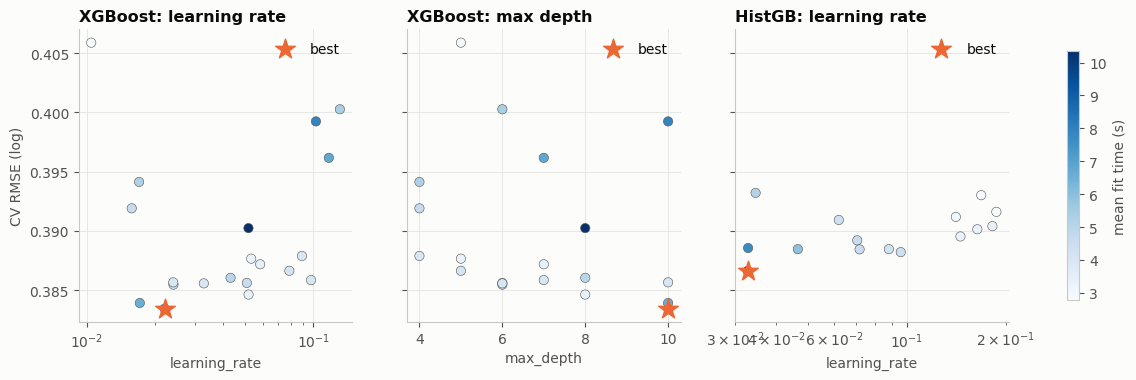

In [8]:
# What mattered in the boosting searches? CV RMSE of every candidate against its key settings
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
panels = [(res_xgb, "param_model__learning_rate", "XGBoost: learning rate", True),
          (res_xgb, "param_model__max_depth", "XGBoost: max depth", False),
          (res_hgb, "param_model__learning_rate", "HistGB: learning rate", True)]
for ax, (res, p, title, logx) in zip(axes, panels):
    sc = ax.scatter(res[p].astype(float), -res["mean_test_RMSE"], c=res["mean_fit_time"], cmap="Blues", s=45, edgecolor=INK2, lw=.4)
    best_row = res.loc[res["rank_test_RMSE"] == 1].iloc[0]
    ax.scatter(float(best_row[p]), -best_row["mean_test_RMSE"], marker="*", s=220, color=ORANGE, zorder=4, label="best")
    if logx:
        ax.set_xscale("log")
    ax.set_title(title); ax.set_xlabel(p.replace("param_model__", "")); ax.legend(loc="upper right")
axes[0].set_ylabel("CV RMSE (log)")
fig.colorbar(sc, ax=axes, label="mean fit time (s)", shrink=.85)
save(fig, "05_boosting_search")

**Reading the result**
- **XGBoost (best CV RMSE 0.3834 vs 0.3929 at defaults).** The winning setting combines a **small learning rate (0.022) with many trees (1,257)**: each tree makes a small correction. **Deep trees (depth 10)** capture interactions such as size × room type × location, and they are kept in check by regularisation: `min_child_weight = 15` (no leaf for a handful of listings), `colsample_bytree = 0.48` (each tree sees half the features) and `subsample = 0.84`. The left panel shows the main pattern: **learning rates ≥ 0.1 give the worst results (0.396–0.400)**, because large steps over-fit quickly.
- **HistGradientBoosting (0.3866 vs 0.3935):** the same story. The best setting has a small learning rate (0.033), large trees (125 leaves) and a large minimum leaf size (62).
- **Random Forest (0.3922 vs 0.3931): only a 0.2% gain.** The best setting uses `max_features = 0.2`. More randomness per split makes the trees less alike, so averaging them cancels more error. A forest's error is driven by the bias of its individual trees, which tuning barely changes, so the defaults were already close to optimal.
- **Timing note:** one Random Forest candidate shows a mean fit time of 130 s (others: 8–22 s). The computer was briefly suspended during that run. This affects the reported search time only, not the scores.

## 6. Tuned vs baseline models

In [9]:
rows = []
for name in stage6.index.drop("Mean baseline"):
    base = stage6.loc[name]
    if name in searches:
        s = searches[name]
        i = s.best_index_
        cvr = s.cv_results_
        tuned = {"tuned RMSE": -cvr["mean_test_RMSE"][i], "tuned RMSE std": cvr["std_test_RMSE"][i],
                 "tuned MAE (log)": -cvr["mean_test_MAE"][i], "tuned R²": cvr["mean_test_R2"][i],
                 "candidates": len(cvr["params"]), "search time (s)": search_time[name],
                 "best settings": {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in s.best_params_.items()}}
    else:   # Linear Regression has no hyper-parameters
        tuned = {"tuned RMSE": base["RMSE (log)"], "tuned RMSE std": base["RMSE std"], "tuned MAE (log)": base["MAE (log)"],
                 "tuned R²": base["R²"], "candidates": 0, "search time (s)": 0.0, "best settings": "– (no hyper-parameters)"}
    rows.append({"model": name, "family": base["family"], "baseline RMSE": base["RMSE (log)"], "baseline R²": base["R²"], **tuned})
tuning = pd.DataFrame(rows).set_index("model")
tuning["RMSE improvement (%)"] = 100 * (tuning["baseline RMSE"] - tuning["tuned RMSE"]) / tuning["baseline RMSE"]
tuning = tuning.sort_values("tuned RMSE")
tuning.to_csv(RESULTS_DIR / "stage7_tuned_vs_baseline.csv")
tuning.drop(columns="best settings").style.format({
    "baseline RMSE": "{:.4f}", "tuned RMSE": "{:.4f}", "tuned RMSE std": "{:.4f}", "tuned MAE (log)": "{:.4f}",
    "baseline R²": "{:.3f}", "tuned R²": "{:.3f}", "search time (s)": "{:.0f}", "RMSE improvement (%)": "{:+.1f}"})

,family,baseline RMSE,baseline R²,tuned RMSE,tuned RMSE std,tuned MAE (log),tuned R²,candidates,search time (s),RMSE improvement (%)
model,,,,,,,,,,
XGBoost,boosting ensemble,0.3929,0.701,0.3834,0.0062,0.2744,0.716,20,884,+2.4
HistGradientBoosting,boosting ensemble,0.3935,0.701,0.3866,0.0056,0.2778,0.711,15,400,+1.7
Random Forest,bagging ensemble,0.3931,0.701,0.3922,0.0070,0.2805,0.703,6,1041,+0.2
Linear Regression,linear,0.4168,0.664,0.4168,0.0069,0.3034,0.664,0,0,+0.0
Ridge,linear,0.4172,0.663,0.4168,0.0062,0.3034,0.664,11,135,+0.1
Lasso,linear,0.4183,0.662,0.4173,0.0062,0.3039,0.663,7,123,+0.3
KNN,instance-based,0.4472,0.613,0.4283,0.0075,0.3117,0.645,8,126,+4.2


,best settings
model,
XGBoost,"{'colsample_bytree': 0.4837, 'learning_rate': 0.0221, 'max_depth': 10, 'min_child_weight': 15, 'n_estimators': 1257,..."
HistGradientBoosting,"{'l2_regularization': 0.0061, 'learning_rate': 0.0327, 'max_features': 0.5952, 'max_iter': 537, 'max_leaf_nodes': 12..."
Random Forest,"{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.2, 'max_depth': 25}"
Linear Regression,– (no hyper-parameters)
Ridge,{'alpha': 0.01}
Lasso,{'alpha': 0.0001}
KNN,"{'n_neighbors': 20, 'weights': 'distance'}"


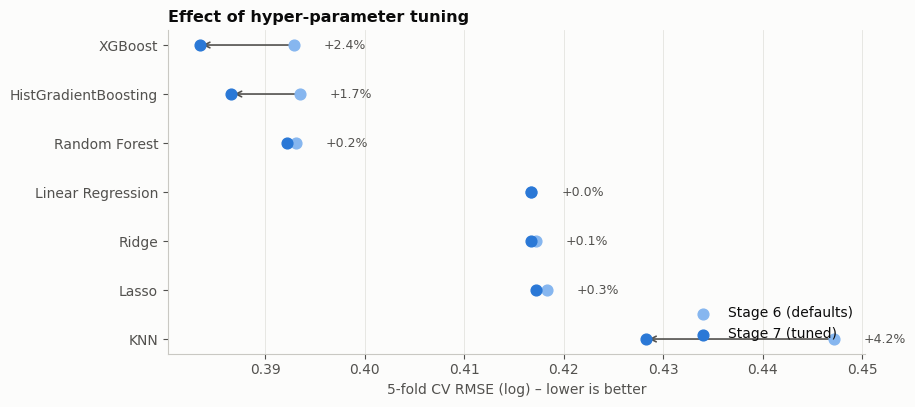

In [10]:
display(tuning[["best settings"]])
fig, ax = plt.subplots(figsize=(9, 4.2))
order = tuning.index[::-1]
for i, n in enumerate(order):
    ax.annotate("", xy=(tuning.loc[n, "tuned RMSE"], i), xytext=(tuning.loc[n, "baseline RMSE"], i),
                arrowprops={"arrowstyle": "->", "color": INK2, "lw": 1.2})
ax.scatter(tuning.loc[order, "baseline RMSE"], range(len(order)), color=BLUE_LIGHT, s=60, label="Stage 6 (defaults)", zorder=3)
ax.scatter(tuning.loc[order, "tuned RMSE"], range(len(order)), color=BLUE, s=60, label="Stage 7 (tuned)", zorder=3)
for i, n in enumerate(order):
    ax.text(max(tuning.loc[n, ["baseline RMSE", "tuned RMSE"]]) + .003, i, f"{tuning.loc[n, 'RMSE improvement (%)']:+.1f}%",
            va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.set_xlabel("5-fold CV RMSE (log) – lower is better")
ax.set_title("Effect of hyper-parameter tuning"); ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
save(fig, "06_tuned_vs_baseline")

**Reading the result**
- **Tuning helps every model with hyper-parameters, but by very different amounts:** KNN +4.2%, XGBoost +2.4%, HistGB +1.7%, Lasso +0.3%, Random Forest +0.2%, Ridge +0.1%.
- **Tuning separated the three tied ensembles.** At defaults they were within 0.0006 of each other. After tuning, **XGBoost leads (0.3834, R² 0.716)**, ahead of HistGB (0.3866, R² 0.711) and Random Forest (0.3922, R² 0.703). Boosting has several capacity-and-regularisation knobs that suit this data (learning rate × number of trees, depth, subsampling). Random Forest has few knobs that reduce bias.
- **The order of the families is unchanged:** boosting > bagging > linear > KNN. Tuning moved models *within* families more than it closed the gaps *between* them, which agrees with the Stage 6 learning-curve diagnosis (linear = bias-limited).
- **Caveat:** a best-of-N CV score is slightly optimistic, because the best candidate was chosen on the same folds. This is why the final test-set check in §9 matters. There, every model's test RMSE is within 0.004 of its tuned CV score.

## 7. Do feature engineering, feature selection or other modelling choices help?
All experiments use the **best tuned model** with its tuned settings and the same 5 folds. Only one thing changes at a time (an **ablation study**). Every learned step, including the feature-selection step in 7c, sits inside the pipeline and is refitted per fold.

In [11]:
BEST = tuning.index[0]
BEST_PARAMS = searches[BEST].best_params_
print(f"Best tuned model: {BEST}")

def tuned_pipeline(feature_set="listing", drop=None, **prep_kwargs):
    return md.make_pipeline(BEST, feature_set, drop=drop, **prep_kwargs).set_params(**BEST_PARAMS)

experiments, oof7 = {}, {}
def experiment(label, question, pipe):
    t0 = time.perf_counter()
    folds, oof7[label] = md.cross_validate_model(pipe, X_train, y_train)
    s = md.summarise_folds(folds)
    experiments[label] = {"question": question, "CV RMSE": s["RMSE (log)"], "RMSE std": s["RMSE std"], "R²": s["R²"],
                          "MAE ($)": s["MAE ($)"], "within ±25% (%)": s["within ±25% (%)"], "fit time (s)": s["fit time (s)"]}
    print(f"{label:38s} CV RMSE {s['RMSE (log)']:.4f} | R² {s['R²']:.3f} | {time.perf_counter() - t0:4.0f} s")

experiment("reference: tuned, listing features", "–", tuned_pipeline())

Best tuned model: XGBoost


reference: tuned, listing features     CV RMSE 0.3834 | R² 0.716 | 12460 s


### 7a. Feature engineering: remove one engineered group at a time
If removing a group makes the error **rise**, the Stage 4 features are pulling their weight.

In [12]:
RATIOS = ("guests_per_bedroom", "beds_per_guest", "guests_per_bathroom")
ablations = {
    "− ratio features": ("Are the capacity ratios useful?", {"columns": RATIOS}),
    "− dist_centre_km": ("Is distance to the centre useful?", {"columns": ("dist_centre_km",)}),
    "− neighbourhood target encoding": ("Is the encoded neighbourhood useful?", {"columns": ("neighbourhood",)}),
    "− amenity flags (keep count)": ("Are the 53 amenity flags useful?", {"prefixes": ("amen_",)}),
    "− all engineered features": ("Is feature engineering useful overall?",
                                  {"columns": RATIOS + ("dist_centre_km", "amenity_count", "is_studio"), "prefixes": ("amen_",)}),
}
for label, (question, drop) in ablations.items():
    experiment(label, question, tuned_pipeline(drop=drop))

− ratio features                       CV RMSE 0.3828 | R² 0.717 |  106 s


− dist_centre_km                       CV RMSE 0.3846 | R² 0.714 |   74 s


− neighbourhood target encoding        CV RMSE 0.3831 | R² 0.716 |   71 s


− amenity flags (keep count)           CV RMSE 0.3963 | R² 0.696 |   57 s


− all engineered features              CV RMSE 0.4002 | R² 0.690 |   57 s


### 7b. Feature set and amenity vocabulary

In [13]:
experiment("full feature set (+ host & history)", "How much do post-listing features add?", tuned_pipeline("full"))
experiment("amenity vocabulary ≥ 1% of listings", "More amenity flags?", tuned_pipeline(amenity_min_prevalence=0.01))
experiment("amenity vocabulary ≥ 5% of listings", "Fewer amenity flags?", tuned_pipeline(amenity_min_prevalence=0.05))

full feature set (+ host & history)    CV RMSE 0.3632 | R² 0.745 |   75 s


amenity vocabulary ≥ 1% of listings    CV RMSE 0.3831 | R² 0.716 |   93 s


amenity vocabulary ≥ 5% of listings    CV RMSE 0.3830 | R² 0.716 |   62 s


### 7c. Feature selection: keep only the top-k features
`SelectFromModel` ranks features by the importance of a quick XGBoost model and keeps the top *k*. It sits **inside** the pipeline, so the ranking is learned on each training fold only. If a ranking were computed on all the training data first, the validation folds would influence which features are kept, which is a subtle form of leakage.

In [14]:
def selected_pipeline(k):
    base = tuned_pipeline()
    selector = SelectFromModel(XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method="hist",
                                            n_jobs=-1, random_state=RANDOM_STATE), max_features=k, threshold=-np.inf)
    return Pipeline([("prep", base.named_steps["prep"]), ("select", selector), ("model", base.named_steps["model"])])

n_features = tuned_pipeline().named_steps["prep"].fit(X_train, y_train).transform(X_train.head(5)).shape[1]
print(f"The listing pipeline produces {n_features} features")
for k in [20, 40]:
    experiment(f"feature selection: top {k} of {n_features}", "Does removing weak features help?", selected_pipeline(k))

The listing pipeline produces 90 features


feature selection: top 20 of 90        CV RMSE 0.4045 | R² 0.684 |   58 s


feature selection: top 40 of 90        CV RMSE 0.3877 | R² 0.709 |   61 s


### 7d. Ensembling: averaging the tuned tree models
Boosting and bagging make different errors, so averaging their predictions can cancel some of them out. We use the **out-of-fold** predictions of each tuned model on the same folds. A simple average learns no weights, so no validation information leaks into it.

In [15]:
tree_models = [m for m in tuning.index if md.MODELS[m][1] in ("boosting ensemble", "bagging ensemble")]
for m in tree_models:
    if m != BEST:
        folds, oof7[m] = md.cross_validate_model(searches[m].best_estimator_.set_params(memory=None), X_train, y_train)
        print(f"{m:22s} tuned OOF RMSE {md.regression_metrics(y_train, oof7[m])['RMSE (log)']:.4f}")
oof7[BEST] = oof7["reference: tuned, listing features"]

blends = {"average of the two boosting models": [m for m in tree_models if md.MODELS[m][1] == "boosting ensemble"],
          "average of all three tree ensembles": tree_models}
for label, members in blends.items():
    pred = np.mean([oof7[m] for m in members], axis=0)
    folds = pd.DataFrame([{**md.regression_metrics(y_train.iloc[va], pred[va])} for _, va in md.CV.split(X_train)])
    experiments[label] = {"question": "Does averaging models help?", "CV RMSE": folds["RMSE (log)"].mean(),
                          "RMSE std": folds["RMSE (log)"].std(), "R²": folds["R²"].mean(), "MAE ($)": folds["MAE ($)"].mean(),
                          "within ±25% (%)": folds["within ±25% (%)"].mean(), "fit time (s)": np.nan}
    print(f"{label:38s} CV RMSE {folds['RMSE (log)'].mean():.4f} | members: {', '.join(members)}")

HistGradientBoosting   tuned OOF RMSE 0.3867


Random Forest          tuned OOF RMSE 0.3923
average of the two boosting models     CV RMSE 0.3831 | members: XGBoost, HistGradientBoosting
average of all three tree ensembles    CV RMSE 0.3834 | members: XGBoost, HistGradientBoosting, Random Forest


,experiment,question,CV RMSE,RMSE std,R²,MAE ($),within ±25% (%),fit time (s),Δ RMSE vs reference,verdict
"reference: tuned, listing features",S7-01,–,0.3834,0.0070,0.716,$48.62,58.4,2489.4,+0.0000,reference
− ratio features,S7-02,Are the capacity ratios useful?,0.3828,0.0069,0.717,$48.55,58.2,18.8,-0.0006,no meaningful change (|Δ| ≤ 0.002)
− dist_centre_km,S7-03,Is distance to the centre useful?,0.3846,0.0071,0.714,$48.81,58.2,12.7,+0.0011,no meaningful change (|Δ| ≤ 0.002)
− neighbourhood target encoding,S7-04,Is the encoded neighbourhood useful?,0.3831,0.0063,0.716,$48.65,58.4,12.1,-0.0003,no meaningful change (|Δ| ≤ 0.002)
− amenity flags (keep count),S7-05,Are the 53 amenity flags useful?,0.3963,0.0075,0.696,$50.40,56.6,9.4,+0.0129,worse → keep the feature / choice as is
− all engineered features,S7-06,Is feature engineering useful overall?,0.4002,0.0070,0.690,$50.90,56.1,9.3,+0.0168,worse → keep the feature / choice as is
full feature set (+ host & history),S7-07,How much do post-listing features add?,0.3632,0.0060,0.745,$46.11,61.1,12.9,-0.0203,better
amenity vocabulary ≥ 1% of listings,S7-08,More amenity flags?,0.3831,0.0071,0.716,$48.67,58.4,16.1,-0.0003,no meaningful change (|Δ| ≤ 0.002)
amenity vocabulary ≥ 5% of listings,S7-09,Fewer amenity flags?,0.3830,0.0069,0.716,$48.68,58.3,10.4,-0.0004,no meaningful change (|Δ| ≤ 0.002)
feature selection: top 20 of 90,S7-10,Does removing weak features help?,0.4045,0.0066,0.684,$51.41,55.7,9.4,+0.0211,worse → keep the feature / choice as is


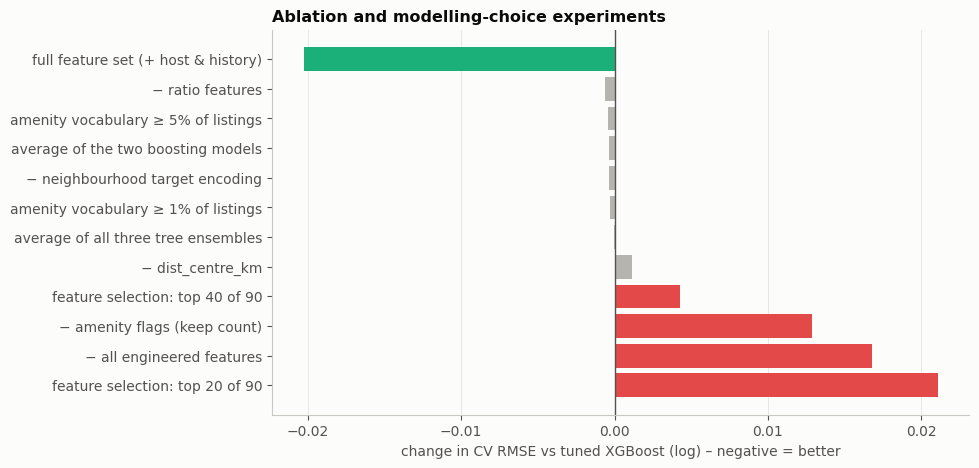

In [16]:
exp = pd.DataFrame(experiments).T
ref = exp.loc["reference: tuned, listing features", "CV RMSE"]
exp["Δ RMSE vs reference"] = exp["CV RMSE"].astype(float) - ref
exp["verdict"] = np.select([exp["Δ RMSE vs reference"] > 0.002, exp["Δ RMSE vs reference"] < -0.002],
                           ["worse → keep the feature / choice as is", "better"], "no meaningful change (|Δ| ≤ 0.002)")
exp.loc["reference: tuned, listing features", "verdict"] = "reference"
exp.insert(0, "experiment", [f"S7-{i + 1:02d}" for i in range(len(exp))])
exp.to_csv(RESULTS_DIR / "stage7_experiments.csv")
display(exp.style.format({"CV RMSE": "{:.4f}", "RMSE std": "{:.4f}", "R²": "{:.3f}", "MAE ($)": "${:.2f}",
                          "within ±25% (%)": "{:.1f}", "fit time (s)": "{:.1f}", "Δ RMSE vs reference": "{:+.4f}"}, na_rep="–"))

fig, ax = plt.subplots(figsize=(9, 5))
e = exp.drop("reference: tuned, listing features").sort_values("Δ RMSE vs reference")
colors = [AQUA if d < -0.002 else (RED if d > 0.002 else "#b5b4ae") for d in e["Δ RMSE vs reference"]]
ax.barh(e.index[::-1], e["Δ RMSE vs reference"][::-1], color=colors[::-1])
ax.axvline(0, color=INK2, lw=1)
ax.set_xlabel(f"change in CV RMSE vs tuned {BEST} (log) – negative = better")
ax.set_title("Ablation and modelling-choice experiments"); ax.grid(axis="y", visible=False)
save(fig, "07_experiments")

**Reading the result** (tuned XGBoost, CV RMSE 0.3834; fold-to-fold std ≈ 0.007)

*Feature engineering (7a)*
- **Engineered features help overall:** removing all of them raises RMSE by **+0.017** (R² 0.716 → 0.690, MAE +$2.3 per night). This is the largest effect of any listing-level change.
- **The amenity flags carry most of that value** (+0.013 when removed, keeping only the count). *Which* amenities a listing has matters much more than *how many*.
- **The ratio features, `dist_centre_km` and the neighbourhood target encoding have no meaningful effect *on XGBoost* (|Δ| ≤ 0.002).** A depth-10 boosted model can rebuild most of this information from the raw inputs: ratios from the raw counts, and location from latitude/longitude and city. **We keep them anyway.** They clearly help the linear models (Stage 4 §6, §14). The neighbourhood encoding is the main location signal when a host types only a neighbourhood and no coordinates. Removing them would not improve accuracy.

*Feature set and amenity vocabulary (7b)*
- **Full feature set: −0.020 RMSE (R² 0.745).** This is the biggest single gain, but those features do not exist for a new listing (EDA §16). It is reported as the upper bound for existing hosts and **not used** in the deployed model.
- **Amenity vocabulary at 1% or 5% instead of 2%: no change** (±0.0004). The 2% threshold from Stage 4 is kept.

*Feature selection (7c)*
- **Keeping only the top 40 (+0.004) or top 20 (+0.021) features makes the model worse.** The "weak" features still add information together. XGBoost already guards against noisy features through column subsampling and regularisation. **Decision: keep all 90 features.** Feature selection was done where it was useful: the variance and correlation filters in Stage 4, plus Lasso's embedded selection for the linear model in §3.

*Ensembling (7d)*
- **Averaging XGBoost with HistGB (−0.0004) or with both other ensembles (±0.0000) gives no meaningful gain.** The three tree models make very similar errors (they learn from the same features), so there is little error left for averaging to cancel.

*Timing note:* the reference row's fit time (2,489 s) is inflated because the computer was suspended during that run. A tuned XGBoost fit really takes ≈ 13 s (search mean fit time: 12.9 s).

## 8. Final model selection
**Rule fixed before looking at the test set:** the final model is the single tuned model with the lowest CV RMSE on the deployable `listing` features. An ensemble replaces it only if it lowers CV RMSE by **more than 0.005**. That is roughly the fold-to-fold noise, and a blend doubles training/serving cost and makes the system harder to explain and maintain.

The table adds practical criteria for deployment: prediction speed for **one** listing (what the web form needs), model size, and stability across folds.

In [17]:
def one_listing_latency(pipe, n=30):
    row = X_train.iloc[[0]]
    pipe.predict(row)
    t0 = time.perf_counter()
    for _ in range(n):
        pipe.predict(row)
    return 1000 * (time.perf_counter() - t0) / n

def size_mb(obj):
    path = CACHE_DIR / "size_probe.joblib"          # written to disk, not RAM: a deep forest can be > 1 GB
    joblib.dump(obj, path)
    mb = path.stat().st_size / 1e6
    path.unlink()
    return mb

crit = []
for name in tuning.index:
    est = searches[name].best_estimator_.set_params(memory=None) if name in searches else \
        md.make_pipeline(name, "listing").fit(X_train, y_train)
    crit.append({"model": name, "CV RMSE": tuning.loc[name, "tuned RMSE"], "RMSE std": tuning.loc[name, "tuned RMSE std"],
                 "CV R²": tuning.loc[name, "tuned R²"], "1-listing prediction (ms)": one_listing_latency(est),
                 "model size (MB)": size_mb(est),
                 "interpretability": {"linear": "high (coefficients)", "instance-based": "medium (similar listings)"}.get(
                     md.MODELS[name][1], "medium (importance, partial dependence)")})
criteria = pd.DataFrame(crit).set_index("model")
display(criteria.style.format({"CV RMSE": "{:.4f}", "RMSE std": "{:.4f}", "CV R²": "{:.3f}",
                               "1-listing prediction (ms)": "{:.1f}", "model size (MB)": "{:.1f}"}))

best_blend = min(blends, key=lambda b: experiments[b]["CV RMSE"])
gain = ref - experiments[best_blend]["CV RMSE"]
USE_BLEND = gain > 0.005
FINAL_NAME = f"Ensemble ({best_blend})" if USE_BLEND else BEST
print(f"Best single model: {BEST} (CV RMSE {ref:.4f}) | best blend gains {gain:+.4f} → "
      f"{'adopt the blend' if USE_BLEND else 'not worth the extra complexity'}")
print(f"FINAL MODEL: {FINAL_NAME}")

,CV RMSE,RMSE std,CV R²,1-listing prediction (ms),model size (MB),interpretability
model,,,,,,
XGBoost,0.3834,0.0062,0.716,37.4,24.5,"medium (importance, partial dependence)"
HistGradientBoosting,0.3866,0.0056,0.711,35.6,8.9,"medium (importance, partial dependence)"
Random Forest,0.3922,0.0070,0.703,98.1,816.3,"medium (importance, partial dependence)"
Linear Regression,0.4168,0.0069,0.664,32.8,2.8,high (coefficients)
Ridge,0.4168,0.0062,0.664,32.1,2.8,high (coefficients)
Lasso,0.4173,0.0062,0.663,34.1,2.8,high (coefficients)
KNN,0.4283,0.0075,0.645,40.9,44.5,medium (similar listings)


Best single model: XGBoost (CV RMSE 0.3834) | best blend gains +0.0004 → not worth the extra complexity
FINAL MODEL: XGBoost


**Final model: tuned XGBoost on the deployable `listing` features.**

| Criterion | Evidence | Verdict |
|---|---|---|
| Accuracy | Lowest CV RMSE of all models (0.3834, R² 0.716). HistGB is a close second (0.3866), then Random Forest (0.3922) | ✔ best |
| Stability | Fold-to-fold std 0.006, similar to the other models | ✔ |
| Ensembles | Best blend improves CV RMSE by only 0.0004, far below the 0.005 rule | single model is enough |
| Speed | 37 ms to price one listing, including all preprocessing. Fast enough for a web form | ✔ |
| Size | 24.5 MB (10 MB compressed). Random Forest would be **816 MB** for worse accuracy | ✔ |
| Deployability | Uses only what a host can enter. Same pipeline object as in CV | ✔ |
| Interpretability | Less transparent than Ridge, but explained with permutation importance and partial dependence (§10) | acceptable |

**Why not the alternatives?**
- **Linear models:** fully interpretable, but 0.033 worse RMSE (about $4.8 more error per night), and their bias cannot be tuned away.
- **Random Forest:** less accurate, 2.6× slower to predict, and 33× larger.
- **HistGradientBoosting:** a strong, smaller alternative (8.9 MB) that would be our fallback. Its CV error is 0.003 higher.
- **An ensemble:** no measurable gain, with twice the complexity.

## 9. Final evaluation on the test set (used once)
The final model was refitted on **all 59,287 training listings** with its chosen settings. It is now scored on the **14,822 test listings** that no step of Stages 4–7 has seen. This is the honest estimate of how it will perform on new listings.

In [18]:
if USE_BLEND:
    final_model = VotingRegressor([(m, searches[m].best_estimator_.set_params(memory=None)) for m in blends[best_blend]])
    final_model.fit(X_train, y_train)
else:
    final_model = searches[BEST].best_estimator_.set_params(memory=None)   # refitted on the full training set by the search

pred_test = final_model.predict(X_test)
test_metrics = md.regression_metrics(y_test, pred_test)
mean_model = DummyRegressor().fit(X_train, y_train)
cv_ref = pd.Series(experiments[best_blend if USE_BLEND else "reference: tuned, listing features"])
cv_metrics = {"RMSE (log)": cv_ref["CV RMSE"], "R²": cv_ref["R²"], "MAE ($)": cv_ref["MAE ($)"], "within ±25% (%)": cv_ref["within ±25% (%)"]}
final_eval = pd.DataFrame({"CV estimate (train)": cv_metrics, f"TEST – {FINAL_NAME}": test_metrics,
                           "TEST – mean baseline": md.regression_metrics(y_test, mean_model.predict(X_test))})
final_eval.to_csv(RESULTS_DIR / "stage7_final_test_metrics.csv")
final_eval

,CV estimate (train),TEST – XGBoost,TEST – mean baseline
RMSE (log),0.3834,0.3808,0.7088
R²,0.7157,0.7114,-0.0000
MAE ($),48.6166,47.8081,86.7989
within ±25% (%),58.4142,59.1216,29.0986
MAE (log),NaN,0.2715,0.5573
MedAE ($),NaN,21.5252,50.3824
MAPE (%),NaN,28.2308,61.7612


In [19]:
# For information only (the choice above is already locked): every tuned model on the test set
info = {}
for name in tuning.index:
    est = searches[name].best_estimator_ if name in searches else md.make_pipeline(name, "listing").fit(X_train, y_train)
    info[name] = {"CV RMSE": tuning.loc[name, "tuned RMSE"], "test RMSE": md.regression_metrics(y_test, est.predict(X_test))["RMSE (log)"]}
info = pd.DataFrame(info).T
info["test − CV"] = info["test RMSE"] - info["CV RMSE"]
info

,CV RMSE,test RMSE,test − CV
XGBoost,0.3834,0.3808,-0.0026
HistGradientBoosting,0.3866,0.3858,-0.0008
Random Forest,0.3922,0.3907,-0.0014
Linear Regression,0.4168,0.4165,-0.0003
Ridge,0.4168,0.4165,-0.0002
Lasso,0.4173,0.4170,-0.0003
KNN,0.4283,0.4249,-0.0034


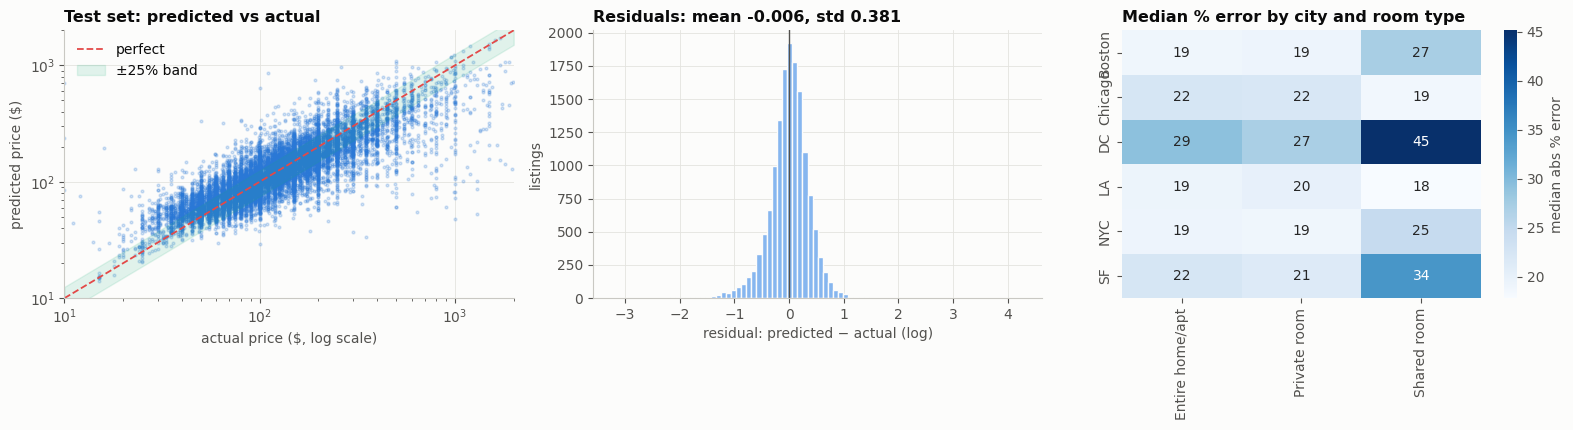

,listings,median_actual,median_predicted,median_abs_pct_error
$10–65,3035,50.0000,60.9007,23.6835
$65–95,2894,80.0000,83.9041,16.3583
$95–135,3032,111.0000,114.8484,17.9681
$135–200,3036,165.0000,158.6831,17.6517
$200–1975,2825,300.0000,245.0827,26.9647


In [20]:
res_test = pd.DataFrame({"actual": np.exp(y_test), "predicted": np.exp(pred_test), "city": X_test["city"], "room_type": X_test["room_type"]})
res_test["abs % error"] = 100 * (res_test["predicted"] / res_test["actual"] - 1).abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ax = axes[0]
ax.scatter(res_test["actual"], res_test["predicted"], s=4, alpha=.2, color=BLUE)
grid = np.array([10, 2000])
ax.plot(grid, grid, color=RED, ls="--", lw=1.3, label="perfect")
ax.fill_between(grid, grid * .75, grid * 1.25, color=AQUA, alpha=.12, label="±25% band")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(10, 2000); ax.set_ylim(10, 2000)
ax.set_xlabel("actual price ($, log scale)"); ax.set_ylabel("predicted price ($)"); ax.set_title("Test set: predicted vs actual"); ax.legend(loc="upper left")

ax = axes[1]
r = y_test - pred_test
ax.hist(pred_test - y_test, bins=80, color=BLUE_LIGHT, edgecolor=SURFACE)
ax.axvline(0, color=INK2, lw=1)
ax.set_xlabel("residual: predicted − actual (log)"); ax.set_ylabel("listings")
ax.set_title(f"Residuals: mean {-r.mean():+.3f}, std {r.std():.3f}")

ax = axes[2]
seg = res_test.groupby(["city", "room_type"])["abs % error"].median().unstack()
sns.heatmap(seg, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "median abs % error"}, ax=ax)
ax.set_title("Median % error by city and room type"); ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()
save(fig, "09_test_evaluation")

by_band = res_test.groupby(pd.qcut(res_test["actual"], 5), observed=True).agg(
    listings=("actual", "size"), median_actual=("actual", "median"), median_predicted=("predicted", "median"),
    median_abs_pct_error=("abs % error", "median"))
by_band.index = [f"${iv.left:.0f}–{iv.right:.0f}" for iv in by_band.index]
by_band

**Reading the result**
- **The test-set performance matches the cross-validation estimate:** RMSE **0.381** (CV 0.383), R² **0.711** (CV 0.716), MAE **$47.8** (CV $48.6). The model generalises to listings it has never seen. The CV procedure was honest, and there was no over-fitting to the validation folds during tuning.
- **For a host:** half of all suggestions are within **$21.50** of the actual price (median error), and **59%** are within ±25%. The mean baseline manages 29%. The model cuts the average error from $86.8 to $47.8 per night (−45%).
- **Every tuned model's test RMSE is within 0.004 of its CV score, and the ranking is identical.** This information table was computed after the choice was locked, and it confirms the selection was not a lucky fold.
- **The residuals are centred on zero (mean −0.006)** and roughly symmetric, so the model is not systematically too high or too low overall.
- **The remaining weakness is regression toward the mean:** the cheapest fifth ($10–65) is over-predicted (median $61 vs $50, 24% error) and the most expensive fifth ($200+) is under-predicted (median $245 vs $300, 27% error). The middle 60% of listings have only 16–18% median error.
- **By segment:** most city/room-type cells have 18–22% median error. **Shared rooms in DC (45%) and SF (34%)** are the weakest, which matches Stage 6. These are small groups with very variable prices.

## 10. Interpreting the final model
### 10a. Which information drives the price? (permutation importance, test set)
Each group of model inputs is shuffled in turn across the test listings. The **increase in RMSE** shows how much the model relies on that group. Dummy columns of one variable (e.g. all `room_type_*`) and all amenity flags are shuffled together, so each variable is measured as a whole.

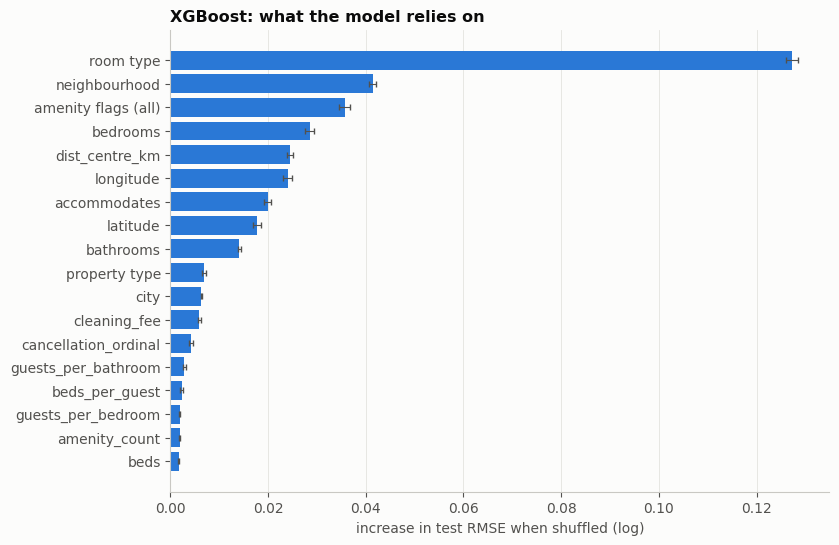

,RMSE increase,std
room type,0.1273,0.0012
neighbourhood,0.0414,0.0007
amenity flags (all),0.0356,0.0011
bedrooms,0.0285,0.0009
dist_centre_km,0.0245,0.0006
longitude,0.0240,0.0010
accommodates,0.0199,0.0007
latitude,0.0177,0.0008
bathrooms,0.0141,0.0004
property type,0.0069,0.0003


In [21]:
explain = final_model if not USE_BLEND else searches[BEST].best_estimator_
Z_test = explain[:-1].transform(X_test)
model_step = explain[-1]
base_rmse = md.regression_metrics(y_test, model_step.predict(Z_test))["RMSE (log)"]

def group_of(col):
    for prefix, g in [("room_type_", "room type"), ("city_", "city"), ("property_type_", "property type"), ("amen_", "amenity flags (all)")]:
        if col.startswith(prefix):
            return g
    return col
groups = pd.Series({c: group_of(c) for c in Z_test.columns})
rng = np.random.default_rng(RANDOM_STATE)
imp = {}
for g, cols in groups.groupby(groups).groups.items():
    cols = list(cols)
    scores = []
    for _ in range(5):
        Zp = Z_test.copy()
        Zp[cols] = Z_test[cols].to_numpy()[rng.permutation(len(Zp))]
        scores.append(md.regression_metrics(y_test, model_step.predict(Zp))["RMSE (log)"] - base_rmse)
    imp[g] = (np.mean(scores), np.std(scores))
imp = pd.DataFrame(imp, index=["RMSE increase", "std"]).T.sort_values("RMSE increase", ascending=False)
imp.to_csv(RESULTS_DIR / "stage7_permutation_importance.csv")

fig, ax = plt.subplots(figsize=(8.5, 6))
top = imp.head(18)[::-1]
ax.barh(top.index, top["RMSE increase"], xerr=top["std"], color=BLUE, error_kw={"ecolor": INK2, "capsize": 2, "lw": .8})
ax.set_xlabel("increase in test RMSE when shuffled (log)"); ax.set_title(f"{FINAL_NAME}: what the model relies on")
ax.grid(axis="y", visible=False)
save(fig, "10a_permutation_importance")
imp.head(18)

### 10b. How does the predicted price respond to each input? (partial dependence)
Each panel sets one feature to a range of values for 3,000 test listings (everything else unchanged) and shows the **average predicted nightly price**.

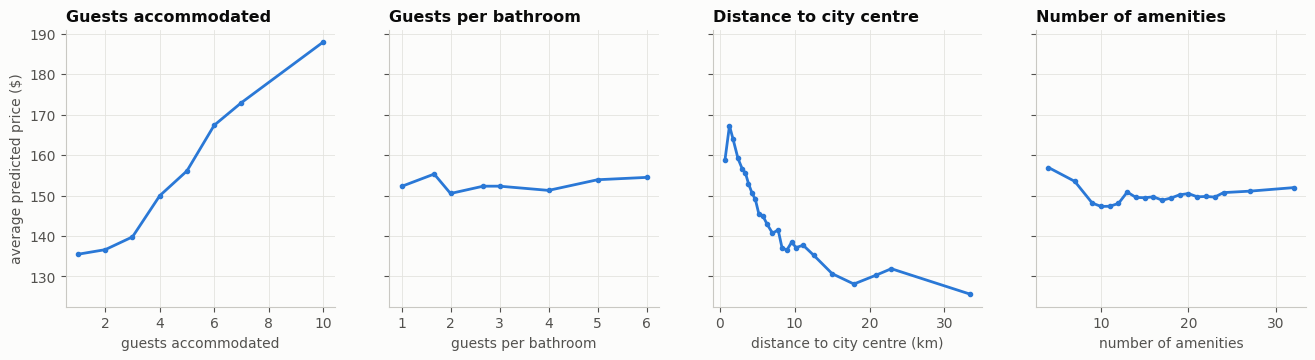

accommodates 2 → 4 guests: average predicted price $137 → $150


In [22]:
sample = Z_test.sample(min(3000, len(Z_test)), random_state=RANDOM_STATE)
pd_feats = [("accommodates", "guests accommodated"), ("guests_per_bathroom", "guests per bathroom"),
            ("dist_centre_km", "distance to city centre (km)"), ("amenity_count", "number of amenities")]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
pdp = {}
for ax, (f, label) in zip(axes, pd_feats):
    grid = np.unique(np.quantile(sample[f], np.linspace(0.02, 0.98, 25)))
    avg = []
    for v in grid:
        Zs = sample.copy(); Zs[f] = v
        avg.append(np.exp(model_step.predict(Zs)).mean())
    pdp[f] = pd.Series(avg, index=grid)
    ax.plot(grid, avg, color=BLUE, marker="o", ms=3)
    ax.set_xlabel(label); ax.set_title(label.split(" (")[0].capitalize())
axes[0].set_ylabel("average predicted price ($)")
save(fig, "10b_partial_dependence")
print("accommodates 2 → 4 guests: average predicted price "
      f"${pdp['accommodates'].iloc[(np.abs(pdp['accommodates'].index - 2)).argmin()]:.0f} → "
      f"${pdp['accommodates'].iloc[(np.abs(pdp['accommodates'].index - 4)).argmin()]:.0f}")

**Reading the result**
- **Room type is by far the most important input** (RMSE +0.127 when shuffled). Whether a guest gets the entire home, a private room or a shared room is the first thing that sets the price (EDA §9: η² = 0.375).
- **Location is the second driver.** Neighbourhood (+0.041), distance to the centre (+0.025), longitude (+0.024) and latitude (+0.018) are all near the top. Because these four overlap, shuffling one at a time *understates* their combined importance.
- **Then amenities (+0.036, all flags together) and size:** bedrooms (+0.029), guests accommodated (+0.020), bathrooms (+0.014).
- **The engineered ratios contribute little on their own (+0.002–0.003).** This agrees with the ablation in §7a.
- **Partial dependence (average predicted price):**
  - **Guests:** $136 for 1 guest → **$150 for 4** → $188 for 10. The steepest rise is between 3 and 6 guests (family-size listings).
  - **Distance to centre:** highest at ~1–2 km (≈ $167), falling to ≈ $137 at 9 km and ≈ $126 at 30+ km. The very centre (< 1 km) is slightly cheaper than 1–2 km.
  - **Number of amenities** and **guests per bathroom** have flat curves. Once the individual amenities and room counts are known, these summaries add nothing, as §7 also showed.
- These patterns match the EDA findings and common sense, which supports trusting the model.

## 11. Saving the final model for the Stage 9 backend
We save the **whole pipeline** (Stage 4 learned preprocessing + tuned model) as one file. The backend therefore only needs two lines, and it applies *exactly* the preprocessing used in development, which is a technical requirement of the brief:
```python
features = pp.clean_and_engineer(form_as_dataframe)     # Layer-1 rules (src/preprocessing.py)
price = np.exp(model.predict(features))                # learned preprocessing + model
```

In [23]:
FINAL_PATH = MODEL_DIR / "final_model.joblib"
joblib.dump(final_model, FINAL_PATH, compress=3)

def jsonable(v):
    return v.item() if hasattr(v, "item") else v
metadata = {
    "model": FINAL_NAME,
    "estimator": type(final_model[-1] if not USE_BLEND else final_model).__name__,
    "feature_set": "listing",
    "target": "log_price (natural log of US$ per night); predict with np.exp(model.predict(X))",
    "input": "DataFrame produced by src.preprocessing.clean_and_engineer(raw_listing_rows)",
    "form_fields": ["city", "neighbourhood", "latitude", "longitude", "room_type", "property_type", "accommodates",
                    "bathrooms", "bedrooms", "beds", "bed_type", "amenities", "cancellation_policy", "cleaning_fee",
                    "instant_bookable"],
    "hyperparameters": ({m: {k.replace("model__", ""): jsonable(v) for k, v in searches[m].best_params_.items()}
                         for m in blends[best_blend]} if USE_BLEND else
                        {k.replace("model__", ""): jsonable(v) for k, v in BEST_PARAMS.items()}),
    "cv_metrics_train": {k: float(v) for k, v in cv_metrics.items()},
    "test_metrics": test_metrics,
    "train_rows": int(len(X_train)), "test_rows": int(len(X_test)),
    "trained_on": str(date.today()),
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                 "xgboost": xgboost.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
(MODEL_DIR / "final_model_metadata.json").write_text(json.dumps(metadata, indent=2, default=str))
print(f"{FINAL_PATH}: {FINAL_PATH.stat().st_size / 1e6:.1f} MB")
print(json.dumps(metadata, indent=2, default=str)[:1500])

models\final_model.joblib: 10.1 MB
{
  "model": "XGBoost",
  "estimator": "XGBRegressor",
  "feature_set": "listing",
  "target": "log_price (natural log of US$ per night); predict with np.exp(model.predict(X))",
  "input": "DataFrame produced by src.preprocessing.clean_and_engineer(raw_listing_rows)",
  "form_fields": [
    "city",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "bed_type",
    "amenities",
    "cancellation_policy",
    "cleaning_fee",
    "instant_bookable"
  ],
  "hyperparameters": {
    "colsample_bytree": 0.4836963163912251,
    "learning_rate": 0.022059149678071027,
    "max_depth": 10,
    "min_child_weight": 15,
    "n_estimators": 1257,
    "reg_alpha": 0.00397211072738191,
    "reg_lambda": 1.524996572521356,
    "subsample": 0.836965827544817
  },
  "cv_metrics_train": {
    "RMSE (log)": 0.38343314533608036,
    "R\u00b2": 0.7156617757064796,
  

In [24]:
# Smoke test exactly as the backend will do it: reload from disk and price a new listing from raw form values
loaded = joblib.load(FINAL_PATH)
form = {"city": "NYC", "neighbourhood": "Williamsburg", "latitude": 40.7081, "longitude": -73.9571,
        "room_type": "Entire home/apt", "property_type": "Apartment", "accommodates": 4, "bathrooms": 1.0,
        "bedrooms": 2, "beds": 2, "bed_type": "Real Bed", "cancellation_policy": "moderate",
        "cleaning_fee": True, "instant_bookable": "f",
        "amenities": '{TV,"Wireless Internet","Air conditioning",Kitchen,Heating,Washer,Dryer,Essentials,"Hair dryer"}'}
what_if = pd.DataFrame([form, {**form, "room_type": "Private room", "accommodates": 2, "bedrooms": 1, "beds": 1},
                        {**form, "city": "LA", "neighbourhood": "Venice", "latitude": 33.9850, "longitude": -118.4695}],
                       index=["2-bed apartment, Williamsburg NYC", "private room, same flat", "same apartment in Venice, LA"])
features = pp.clean_and_engineer(what_if)
what_if["predicted nightly price ($)"] = np.exp(loaded.predict(features)).round(0)
assert np.allclose(loaded.predict(X_test.head(50)), final_model.predict(X_test.head(50))), "reloaded model differs"
what_if[["city", "neighbourhood", "room_type", "accommodates", "bedrooms", "predicted nightly price ($)"]]

,city,neighbourhood,room_type,accommodates,bedrooms,predicted nightly price ($)
"2-bed apartment, Williamsburg NYC",NYC,Williamsburg,Entire home/apt,4,2,183.0000
"private room, same flat",NYC,Williamsburg,Private room,2,1,80.0000
"same apartment in Venice, LA",LA,Venice,Entire home/apt,4,2,199.0000


In [25]:
shutil.rmtree(CACHE_DIR, ignore_errors=True)   # remove the temporary preprocessing cache
for f in sorted(MODEL_DIR.glob("final_model*")) + sorted(RESULTS_DIR.glob("stage7_*")):
    print(f"{str(f):55s} {f.stat().st_size / 1e3:8.1f} kB")

models\final_model.joblib                                10143.9 kB
models\final_model_metadata.json                             1.6 kB
results\stage7_experiments.csv                               3.2 kB
results\stage7_final_test_metrics.csv                        0.5 kB
results\stage7_permutation_importance.csv                    1.2 kB
results\stage7_search_histgradientboosting.csv               9.2 kB
results\stage7_search_knn.csv                                4.6 kB
results\stage7_search_lasso.csv                              4.1 kB
results\stage7_search_random_forest.csv                      3.6 kB
results\stage7_search_ridge.csv                              6.2 kB
results\stage7_search_xgboost.csv                           12.9 kB
results\stage7_tuned_vs_baseline.csv                         2.0 kB


## 12. Summary of Stage 7 decisions, limitations and future work

| Step | Decision | Evidence |
|---|---|---|
| Search strategy | Grid search for 1–2-parameter models (Ridge, Lasso, KNN). Randomised search for tree ensembles (RF 6, HistGB 15, XGBoost 20 candidates) | Grid is exhaustive when cheap; random search scales to 6–8 interacting parameters (§2) |
| Validation | Same 5 training folds as Stage 6; whole pipeline searched; preprocessing cached per fold | Fair tuned-vs-baseline comparison; no leakage |
| Tuning results | XGBoost 0.3929 → **0.3834**, HistGB 0.3935 → 0.3866, RF 0.3931 → 0.3922, KNN 0.447 → 0.428, linear ≈ unchanged | §3–6 |
| Feature engineering | Keep all Stage 4 features: removing them costs +0.017 RMSE (amenity flags +0.013) | §7a |
| Feature selection | No further selection: top-40 / top-20 subsets are worse (+0.004 / +0.021) | §7c |
| Feature set | Deployable `listing` set. `full` is better (−0.020) but unavailable for new listings | §7b, EDA §16 |
| Ensembling | Not adopted: gain 0.0004 < 0.005 rule | §7d, §8 |
| **Final model** | **Tuned XGBoost** (1,257 trees, depth 10, learning rate 0.022, column/row subsampling, L1/L2) inside the Stage 4 pipeline | §8 |
| Test performance | RMSE 0.381 · R² 0.711 · MAE $47.8 · median error $21.5 · 59% within ±25% (baseline 29%) | §9 |
| Deliverable | `models/final_model.joblib` + `final_model_metadata.json`; reload and prediction tested | §11 |

### Limitations
- **The data is a 2017 snapshot of six US cities.** Absolute prices are out of date, and the model should not be used for other cities without retraining.
- **Important price drivers are not in the data:** photos, decor, view, exact building, quality of the description, seasonality and day of week. This causes the regression toward the mean for budget and luxury listings.
- **Weaker segments:** DC and SF, and shared rooms (small groups with variable prices).
- `exp(predicted log price)` estimates the **median** price for a listing profile, not the mean. This is intended (a typical price), but it should be stated in the user interface.
- **The search budget was limited** (6–20 random candidates per ensemble) because of computing time. The best-of-N CV score is slightly optimistic, although the test set showed no sign of this.

### Future improvements
- Show a **price range** (e.g. quantile regression or conformal prediction intervals) instead of a single number. This is most important for budget and luxury listings.
- **Bayesian optimisation** (e.g. Optuna) with early stopping for a more efficient, larger search.
- Add carefully leakage-checked **text features** (e.g. keywords from the description such as "view", "luxury") and **per-listing explanations** (SHAP) in the frontend.
- **Retrain on recent data** and monitor accuracy per city after deployment.